# Target of inference

Assume data generating process:  $(X, y) \sim \Pr_{(X,y)}$ from a GMM with $K$ components:


$\begin{eqnarray*}
  &  y \sim \text{Mult}(\pi, 1) \\
   &  X|y=k \sim \mathcal{N}(\mu_k, \Sigma_k)
\end{eqnarray*}$

In [206]:
import numpy as np

K = 3
p = 2 # number of features
noise_p = 1 # number of noise features
alpha = 3
N = 500
seed = 42
rng = np.random.default_rng(seed)
pi = rng.uniform(0, 1, size=K)
pi /= pi.sum()
mu = rng.choice([-alpha, -alpha/2, 0, +alpha/2, alpha], size=(K, p))
Cov_k = np.array([np.eye(p) for k in range(K)])

def sample_from_P(pi, mu, Cov_k, noise_p, rng):
    cluster_memb = rng.choice(len(pi), p=pi)
    X_signal = rng.multivariate_normal(mean=mu[cluster_memb], cov=Cov_k[cluster_memb])
    X_noise = rng.normal(0, 1, size=noise_p)
    return np.concatenate([X_signal, X_noise]), cluster_memb

def generate_dataset(pi, mu, Cov_k, N, noise_p, rng):
    X = np.empty((N, mu.shape[1] + noise_p))
    y = np.empty(N, dtype=int)
    for i in range(N):
        X[i], y[i] = sample_from_P(pi, mu, Cov_k, noise_p, rng)
    return X, y
    
X, y = generate_dataset(pi, mu, Cov_k, N, noise_p=1, rng=rng)
print(pi, mu)

[0.37363326 0.21187196 0.41449478] [[-3.   1.5]
 [-1.5 -3. ]
 [ 0.   3. ]]


Text(0, 0.5, 'Feature 1')

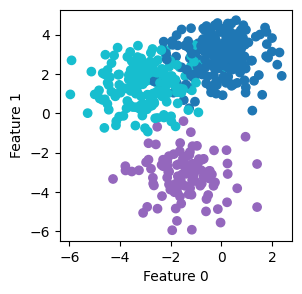

In [138]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10_r')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

## Monte carlo estimate of ToI

Target of inference: $\begin{equation}
    \Delta_j(\{X_i\}_{i \in \mathcal{I}_{tr}}) = \mathbb{E}_{(X^*, y^*)\sim P_{(X,y)} } \bigg[e\bigg(y^*, \hat{f}^{-j}\big(X^*|(X_{i, \setminus j}, c_i)_{i \in \mathcal{I}_{tr}}\big) \bigg) - e\bigg(y^*, \hat{f}\big(X^*|(X_{i}, c_i)_{i \in \mathcal{I}_{tr}}\big) \bigg) \bigg]
\end{equation}$

In [139]:
base_clusterer = KMeans(n_clusters=K)
transfer_clf = RandomForestClassifier()

In [140]:
from clim.utils import hinge_error
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

def compute_target(pi, mu, Cov_k, N_tr, seed, transfer_clf, base_clusterer, error_metric=hinge_error):
    """ 
    Returns for one test point $(X^*, y^*) sim P_{(X,y)}$,
    $begin{equation}
    Delta_j(X^*, y^*;{X_i}_{i in mathcal{I}_{tr}}) = e bigg(y^*, hat{f}^{-j} big(X^*|(X_{i, setminus j}, c_i)_{i in mathcal{I}_{tr}}big) bigg) - e bigg(y^*, hat{f}big(X^*|(X_{i}, c_i)_{i in mathcal{I}_{tr}}big) bigg)
    end{equation}$

    """
    rng = np.random.default_rng(seed)
    # Train data 
    X_tr, y_tr = generate_dataset(pi, mu, Cov_k, N_tr, noise_p = 1, rng=rng)
    c_tr = base_clusterer.fit(X_tr).predict(X_tr)
    f_tr = clone(transfer_clf).fit(X_tr, c_tr)
    
    # Test point 
    X_test, y_test = generate_dataset(pi, mu, Cov_k, 1, noise_p=1, rng=rng) 
    
    # full transfer prediction
    p_pred = f_tr.predict_proba(X_test) 
    
    p = X_tr.shape[1] 
    loco_err = np.zeros((p,))
    for j in range(p):
        X_trj = np.delete(X_tr, j, axis=1)
        f_trj = clone(transfer_clf).fit(X_trj, c_tr)
        X_testj = np.delete(X_test, j, axis=1)
        p_predj = f_trj.predict_proba(X_testj)

        loco_err[j] = (error_metric(y_test, p_predj) - error_metric(y_test, p_pred)).item()
    return loco_err

In [142]:
loco_err = compute_target(pi, mu, Cov_k, N_tr, seed, transfer_clf, base_clusterer, error_metric=hinge_error)
print(loco_err)

[-0.05  0.    0.  ]


In [143]:
from joblib import delayed, Parallel
B = 10000
seed_rng = np.random.default_rng(123)
seeds = seed_rng.integers(0, 100000, size=B)

results_pop = Parallel(n_jobs=-1, verbose=10)(
    delayed(compute_target)(pi, mu, Cov_k, N_tr, int(seed),transfer_clf, base_clusterer, error_metric=hinge_error)
    for seed in seeds
)

Deltas_pop = np.asarray(results_pop)   # shape (B, p_total)

Delta_hat = Deltas_pop.mean(axis=0)
Delta_se = Deltas_pop.std(axis=0, ddof=1) / np.sqrt(B)

print("Population estimate:", Delta_hat)
print("Monte Carlo SE:", Delta_se)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

Population estimate: [-0.019054  0.023387 -0.000613]
Monte Carlo SE: [0.00291276 0.003128   0.00053669]


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  7.9min finished


In [145]:
np.save('./cluster_loco_target_mc_10000.npy', results_pop)

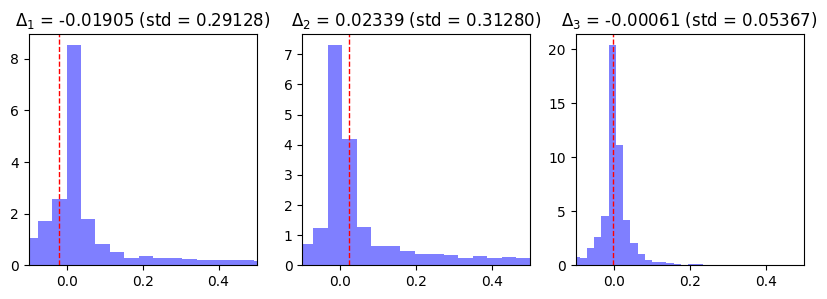

In [147]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
for j in range(3):
    ax[j].hist(Deltas_pop[:,j], bins=50, density=True, alpha=0.5, color='b')
    ax[j].axvline(Delta_hat[j], color='r', linestyle='dashed', linewidth=1)
    ax[j].set_title(r'$\Delta_{%d}$ = %.5f (std = %.5f)' % (j+1, Delta_hat[j], np.std(Deltas_pop[:, j], ddof=1)))
    ax[j].set_xlim((-0.1,0.5))


## Cluster LOCO Split coverage

In [188]:
from clim.utils import hinge_error
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.model_selection import train_test_split

def compute_target_split(pi, mu, Cov_k, N, seed, transfer_clf, base_clusterer, error_metric=hinge_error):
    """ 
    Returns target with split
    """
    rng = np.random.default_rng(seed)
    # Data 
    X, y = generate_dataset(pi, mu, Cov_k, N, noise_p = 1, rng=rng)
    X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)
    c_tr = base_clusterer.fit(X_tr).predict(X_tr)
    c_tr = hungarian_align(y_tr, c_tr) # align the labels
 
    f_tr = clone(transfer_clf).fit(X_tr, c_tr)
    
    # full transfer prediction
    p_pred = f_tr.predict_proba(X_test) 
    
    n, p = X_test.shape
    loco_err = np.zeros((n, p))
    for j in range(p):
        X_trj = np.delete(X_tr, j, axis=1)
        f_trj = clone(transfer_clf).fit(X_trj, c_tr)
        X_testj = np.delete(X_test, j, axis=1)
        p_predj = f_trj.predict_proba(X_testj)
        
        loco_err[:, j] = error_metric(y_test, p_predj) - error_metric(y_test, p_pred)
    return np.mean(loco_err, axis=0)

In [189]:
loco_err = compute_target_split(pi, mu, Cov_k, N_tr, seed, transfer_clf, base_clusterer, error_metric=hinge_error)
print(loco_err)

[ 0.1517   0.2222  -0.04875]


In [250]:
from joblib import delayed, Parallel
B = 10000
seed_rng = np.random.default_rng(123)
seeds = seed_rng.integers(0, 2**32 - 1, size=B)
# seeds = seed_rng.integers(0, 100000, size=B)
N = 800 
results_pop = Parallel(n_jobs=-1, verbose=10)(
    delayed(compute_target_split)(pi, mu, Cov_k, N, int(seed),transfer_clf, base_clusterer, error_metric=hinge_error)
    for seed in seeds
)

Deltas_pop = np.asarray(results_pop)   # shape (B, p_total)

Delta_hat = Deltas_pop.mean(axis=0)
Delta_se = Deltas_pop.std(axis=0, ddof=1) / np.sqrt(B)

print("Population estimate:", Delta_hat)
print("Monte Carlo SE:", Delta_se)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

Population estimate: [ 0.16870668  0.24483736 -0.03138045]
Monte Carlo SE: [1.90230086e-04 1.79099058e-04 5.18406876e-05]


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  8.6min finished


In [251]:
np.save('./cluster_loco_split_target_mc_10000.npy', results_pop)

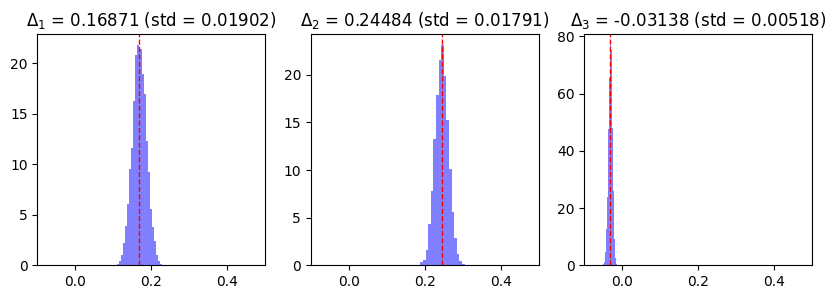

In [252]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
for j in range(3):
    ax[j].hist(Deltas_pop[:,j], bins=50, density=True, alpha=0.5, color='b')
    ax[j].axvline(Delta_hat[j], color='r', linestyle='dashed', linewidth=1)
    ax[j].set_title(r'$\Delta_{%d}$ = %.5f (std = %.5f)' % (j+1, Delta_hat[j], np.std(Deltas_pop[:, j], ddof=1)))
    ax[j].set_xlim((-0.1,0.5))


In [202]:
import clim
from clim.data_splitting import Cluster_LOCO_Split

In [203]:
help(Cluster_LOCO_Split)

Help on function Cluster_LOCO_Split in module clim.data_splitting.generalizability:

Cluster_LOCO_Split(X_tr, X_ca, model=KMeans(), clf=RandomForestClassifier(), K=None, seed=24, error_metric=None, use_proba=True, n_jobs=-1)



In [209]:
mu

array([[-3. ,  1.5],
       [-1.5, -3. ],
       [ 0. ,  3. ]])

In [210]:
rng = np.random.default_rng(seed)
X, y = generate_dataset(pi, mu, Cov_k, N, noise_p = 1, rng=rng)
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)
score, _ = Cluster_LOCO_Split(X_tr, X_test, model=KMeans(n_clusters=K), clf=RandomForestClassifier(), K=K)

n_clusters already set to 3; skipping reset


In [214]:
def fit_cluster_loco(pi, mu, Cov_k, N, seed, transfer_clf, base_clusterer, error_metric=hinge_error):
    rng = np.random.default_rng(seed)
    # Data 
    X, y = generate_dataset(pi, mu, Cov_k, N, noise_p = 1, rng=rng)
    X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)
    score, se = Cluster_LOCO_Split(X_tr, X_test, model=KMeans(n_clusters=K), seed=seed, clf=RandomForestClassifier(), K=K)
    return score, se
   

In [217]:
B = 10000
seed_rng = np.random.default_rng(123)
seeds = seed_rng.integers(0, 100000, size=B)
N = 800 

clim_mc = Parallel(n_jobs=-1, verbose=10)(
    delayed(fit_cluster_loco)(
        pi, mu, Cov_k, N, int(seed),
        transfer_clf, base_clusterer,
        error_metric=hinge_error
    )
    for seed in seeds
)

# Each has shape (R, p_total)
Delta_hat_reps = np.vstack([score for score, se in clim_mc])
Delta_se_reps = np.vstack([se for score, se in clim_mc])

print(Delta_hat_reps.shape)
print(Delta_se_reps.shape)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   11.3s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; ski

[Parallel(n_jobs=-1)]: Done 3026 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 3105 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 3265 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 3346 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 3429 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 3512 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 3597 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 3682 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 3769 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 3856 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 3945 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 4125 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 4216 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 4309 tasks      | elapsed: 


n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; sk

[Parallel(n_jobs=-1)]: Done 4497 tasks      | elapsed:  4.2min


...


n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; sk

[Parallel(n_jobs=-1)]: Done 8962 tasks      | elapsed:  8.0min



n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; sk

[Parallel(n_jobs=-1)]: Done 9097 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 9232 tasks      | elapsed:  8.2min
[Parallel(n_jobs=-1)]: Done 9369 tasks      | elapsed:  8.3min
[Parallel(n_jobs=-1)]: Done 9506 tasks      | elapsed:  8.4min
[Parallel(n_jobs=-1)]: Done 9645 tasks      | elapsed:  8.6min
[Parallel(n_jobs=-1)]: Done 9784 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 9925 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  8.8min finished


ValueError: too many values to unpack (expected 2)

In [218]:
np.save('./cluster_loco_split_est_mc_10000.npy', clim_mc)

In [253]:
theta_pop = Deltas_pop.mean(axis=0)

In [254]:
Delta_hat_reps = np.vstack([score[0] for score in clim_mc])
Delta_se_reps = np.vstack([score[1] for score in clim_mc])

In [255]:
from scipy.stats import norm

alpha = 0.05
z = norm.ppf(1 - alpha / 2)

lower = Delta_hat_reps - z * Delta_se_reps
upper = Delta_hat_reps + z * Delta_se_reps

covered = (
    (lower <= theta_pop[None, :]) &
    (theta_pop[None, :] <= upper)
)

coverage_by_feature = covered[:1000,:].mean(axis=0)
avg_length_by_feature = (upper - lower).mean(axis=0)

coverage_mcse = np.sqrt(
    coverage_by_feature * (1 - coverage_by_feature) / B
)

In [256]:
import numpy as np
import matplotlib.pyplot as plt

def plot_coverage(
    coverage,
    coverage_mcse=None,
    nominal=0.95,
    feature_names=None,
    figsize=(8, 4),
):
    coverage = np.asarray(coverage)
    p = len(coverage)

    if feature_names is None:
        feature_names = [f"Feature {j}" for j in range(p)]

    x = np.arange(p)

    fig, ax = plt.subplots(figsize=figsize)

    ax.errorbar(
        x,
        coverage,
        yerr=coverage_mcse,
        fmt="o",
        capsize=4,
        markersize=6,
        label="Empirical coverage",
    )

    ax.axhline(
        nominal,
        linestyle="--",
        linewidth=1.5,
        label=f"Nominal coverage ({nominal:.0%})",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(feature_names, rotation=45, ha="right")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coverage probability")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False)

    fig.tight_layout()
    return fig, ax

Text(0.5, 1.0, 'Empirical 95% Confidence-Interval Coverage')

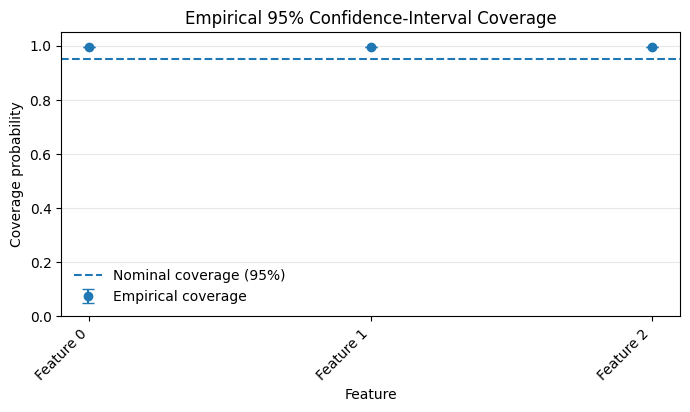

In [257]:
fig, ax = plot_coverage(
    coverage=coverage_by_feature,
    coverage_mcse=coverage_mcse,
    nominal=0.95,
    feature_names=[f"Feature {j}" for j in range(len(coverage_by_feature))],
    figsize=(7, 4),
)

ax.set_title("Empirical 95% Confidence-Interval Coverage")

In [242]:
coverage_mcse

array([0.00059892, 0.00059892, 0.00063119])

In [ ]:
from clim.utils.utils import hungarian_align
from sklearn.mixture import Gaussian
def compute_target_sto(N_tr, N_ca, p_total, K, seed):
    rng = np.random.default_rng(seed)

    base_clusterer = GaussianMixture(n_components=K, random_state=seed)
    base_clf = RandomForestClassifier(random_state=seed)

    # ----- Simulate training data -----
    X, y = [], []
    for _ in range(N_tr):
        X_i, cluster_memb = sample_from_P(pi, mu, Cov_k, noise_p=noise_p, rng=rng)
        X.append(X_i[0, :])
        y.append(cluster_memb)
    X = np.asarray(X)
    y = np.asarray(y)

    # ----- Fit clustering on full data -----
    clust = clone(base_clusterer)
    clust.fit(X)
    # stochastic labels 
    probs = clust.predict_proba(X)  # probabilities for each component
    y_sto = [np.random.multinomial(1, p).argmax() for p in probs]  # sample labels from the GMM probabilities
    labels = hungarian_align(y, y_sto)

    # ----- Simulate calibration/test data -----
    X_new, y_new = [], []
    for _ in range(N_ca):
        X_i, y_i = sample_from_P(pi, mu, Cov_k, noise_p=noise_p, rng=rng)
        X_new.append(X_i[0, :])
        y_new.append(y_i)
    X_new = np.asarray(X_new)
    y_new = np.asarray(y_new)

    # ----- Full-data surrogate error -----
    clf = clone(base_clf)
    clf.fit(X, labels)
    y_pred = clf.predict(X_new)
    e_full = np.mean(np.abs(y_pred - y_new))

    # ----- Leave-one-feature-out errors -----
    delta = np.zeros(p_total, dtype=float)

    for j in range(p_total):
        X_j = np.delete(X, j, axis=1)
        X_new_j = np.delete(X_new, j, axis=1)

        clf_j = clone(base_clf)
        clf_j.fit(X_j, labels)
        y_pred_j = clf_j.predict(X_new_j)

        e_minus_j = np.mean(np.abs(y_pred_j - y_new))
        delta[j] = e_minus_j - e_full

    return delta